# Liver Cancer Gene Expression Analysis
**Team 3: Sai Karthik, Makayla Phillips, Shreya Krishnan**

**Research Question:** *What genes play the most important role in determining risk of hepatic cancer, and how can expression levels of these genes be used to inform diagnosis of liver cancer?*

Dataset: GSE263786

## 1. Read in Data and Understand Data Structure

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("BME 357 Project Data")

# Local TPM-normalized expression matrix (Entrez gene IDs, GRCh38.p13)
expr_path = DATA_DIR / "GSE263786_norm_counts_TPM_GRCh38.p13_NCBI.tsv"
df = pd.read_csv(expr_path, sep="\t", index_col=0)
df.index = df.index.astype(str)  # Entrez IDs as strings for downstream symbol mapping
print("Expression matrix shape:", df.shape)

# Metadata: local CSV (Sample, Description). Disease state from Description.
meta_raw = pd.read_csv(DATA_DIR / "metadata_gse263786.csv")
meta_raw["disease_state"] = np.where(
    meta_raw["Description"].str.contains("Normal Liver", case=False, na=False),
    "Normal", "Disease",
)
meta_df = meta_raw.set_index("Sample")[["disease_state"]].reindex(df.columns)

print("\nDisease distribution:")
print(meta_df["disease_state"].value_counts(dropna=False))
print("\nFinal shapes:")
print("Expression:", df.shape)
print("Metadata:", meta_df.shape)


Expression matrix shape: (39376, 231)

Disease distribution:
disease_state
Disease    207
Normal      24
Name: count, dtype: int64

Final shapes:
Expression: (39376, 231)
Metadata: (231, 1)


## 2. Data Preprocessing
Inspect missingness, apply mean imputation, standard scaling, PCA feature selection, correlation matrix, and histograms of top correlated features.

Missing values per gene (top 10):
Series([], dtype: int64)

Total genes with missing values: 0
Total samples with missing values: 0


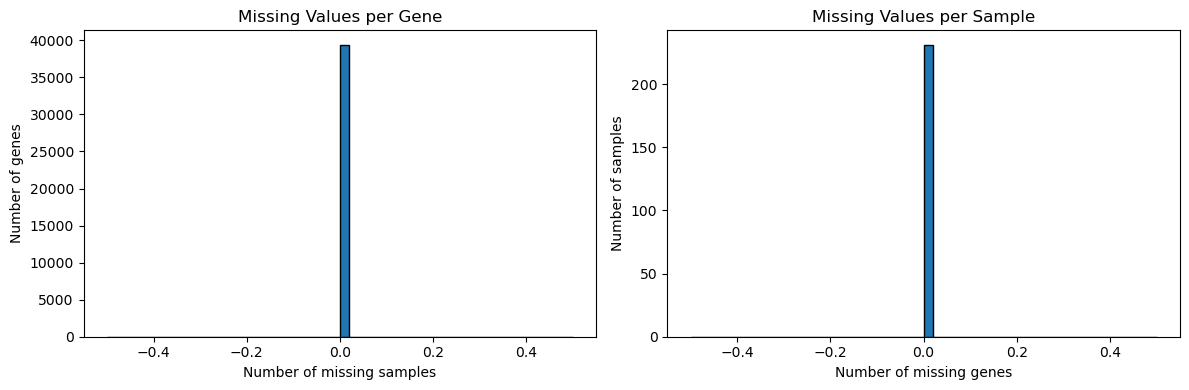

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Inspect missingness ---
missing_per_gene = df.isnull().sum(axis=1)
missing_per_sample = df.isnull().sum(axis=0)
print("Missing values per gene (top 10):")
print(missing_per_gene[missing_per_gene > 0].sort_values(ascending=False).head(10))
print(f"\nTotal genes with missing values: {(missing_per_gene > 0).sum()}")
print(f"Total samples with missing values: {(missing_per_sample > 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(missing_per_gene, bins=50, edgecolor='black')
axes[0].set_title('Missing Values per Gene')
axes[0].set_xlabel('Number of missing samples')
axes[0].set_ylabel('Number of genes')
axes[1].hist(missing_per_sample, bins=50, edgecolor='black')
axes[1].set_title('Missing Values per Sample')
axes[1].set_xlabel('Number of missing genes')
axes[1].set_ylabel('Number of samples')
plt.tight_layout()
plt.show()

In [23]:
# --- Mean imputation ---
df_imputed = df.fillna(df.mean(axis=1).to_dict())
df_imputed = df_imputed.fillna(0)  # any all-NaN rows
print(f"Remaining missing values after imputation: {df_imputed.isnull().sum().sum()}")

# --- Filter low-expression genes (TPM threshold) ---
min_tpm, min_samples = 1.0, 10
gene_mask = (df_imputed > min_tpm).sum(axis=1) >= min_samples
df_filtered = df_imputed.loc[gene_mask]
print(f"Genes after filtering (TPM>{min_tpm} in >={min_samples} samples): {df_filtered.shape[0]}")

# --- Standard scaling ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")


Remaining missing values after imputation: 0
Genes after filtering (TPM>1.0 in >=10 samples): 18325
Scaled data shape: (18325, 231)


In [24]:
from pybiomart import Server

# --- Convert NCBI Entrez Gene IDs to HGNC Symbols via BioMart ---
entrez_ids = df_filtered.index.astype(str).tolist()

server = Server(host="http://www.ensembl.org")
dataset = server.marts["ENSEMBL_MART_ENSEMBL"].datasets["hsapiens_gene_ensembl"]
result = dataset.query(attributes=["entrezgene_id", "hgnc_symbol"])
result.columns = ["entrezgene_id", "hgnc_symbol"]
result = result.dropna(subset=["entrezgene_id"])
result["entrezgene_id"] = result["entrezgene_id"].astype(int).astype(str)

mapping = result[result["hgnc_symbol"].fillna("").str.len() > 0].drop_duplicates("entrezgene_id")
mapping_dict = dict(zip(mapping["entrezgene_id"], mapping["hgnc_symbol"]))

# Map Entrez IDs to symbols (fall back to the Entrez ID if no mapping exists)
new_index = [mapping_dict.get(eid, eid) for eid in entrez_ids]

# Collapse duplicate symbols by keeping the row with highest mean expression
temp_df = df_filtered.copy()
temp_df["symbol"] = new_index
temp_df["mean_expr"] = temp_df.drop(columns=["symbol"]).mean(axis=1)
temp_df = temp_df.sort_values("mean_expr", ascending=False)
temp_df = temp_df[~temp_df["symbol"].duplicated(keep="first")]
temp_df = temp_df.drop(columns=["mean_expr"]).set_index("symbol")

df_filtered = temp_df
print(f"Genes after Entrez-to-symbol conversion: {df_filtered.shape[0]}")
print(f"Genes with HGNC symbols: {sum(1 for g in df_filtered.index if not g.isdigit())}")
print(f"Sample gene names: {df_filtered.index[:10].tolist()}")

# Re-apply standard scaling with new index
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")


Genes after Entrez-to-symbol conversion: 18252
Genes with HGNC symbols: 15552
Sample gene names: ['ALB', 'MT-CO3', 'MT-CO1', 'MT-TS1', '4574', 'MT-ATP6', 'HP', 'MT-CO2', 'MT-ND4', 'APOA2']
Scaled data shape: (18252, 231)


In [25]:
# --- PCA for feature selection ---
from sklearn.decomposition import PCA

X = df_scaled.T.values  # samples x genes
pca_full = PCA()
pca_full.fit(X)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of PCs to retain 90% variance: {n_components_90}")

# Identify top contributing genes from PCA loadings
pca_fit = PCA(n_components=n_components_90)
X_pca = pca_fit.fit_transform(X)

# Gene importance = sum of absolute loadings across retained PCs
loadings = np.abs(pca_fit.components_)  # (n_components x n_genes)
gene_importance = loadings.sum(axis=0)
gene_importance_df = pd.DataFrame({
    'gene': df_scaled.index,
    'pca_importance': gene_importance
}).sort_values('pca_importance', ascending=False)

# Select top genes by PCA importance
n_top_genes = 2000
top_pca_genes = gene_importance_df.head(n_top_genes)['gene'].tolist()
df_selected = df_scaled.loc[top_pca_genes]
print(f"Genes selected via PCA feature selection: {df_selected.shape[0]}")

Number of PCs to retain 90% variance: 52
Genes selected via PCA feature selection: 2000


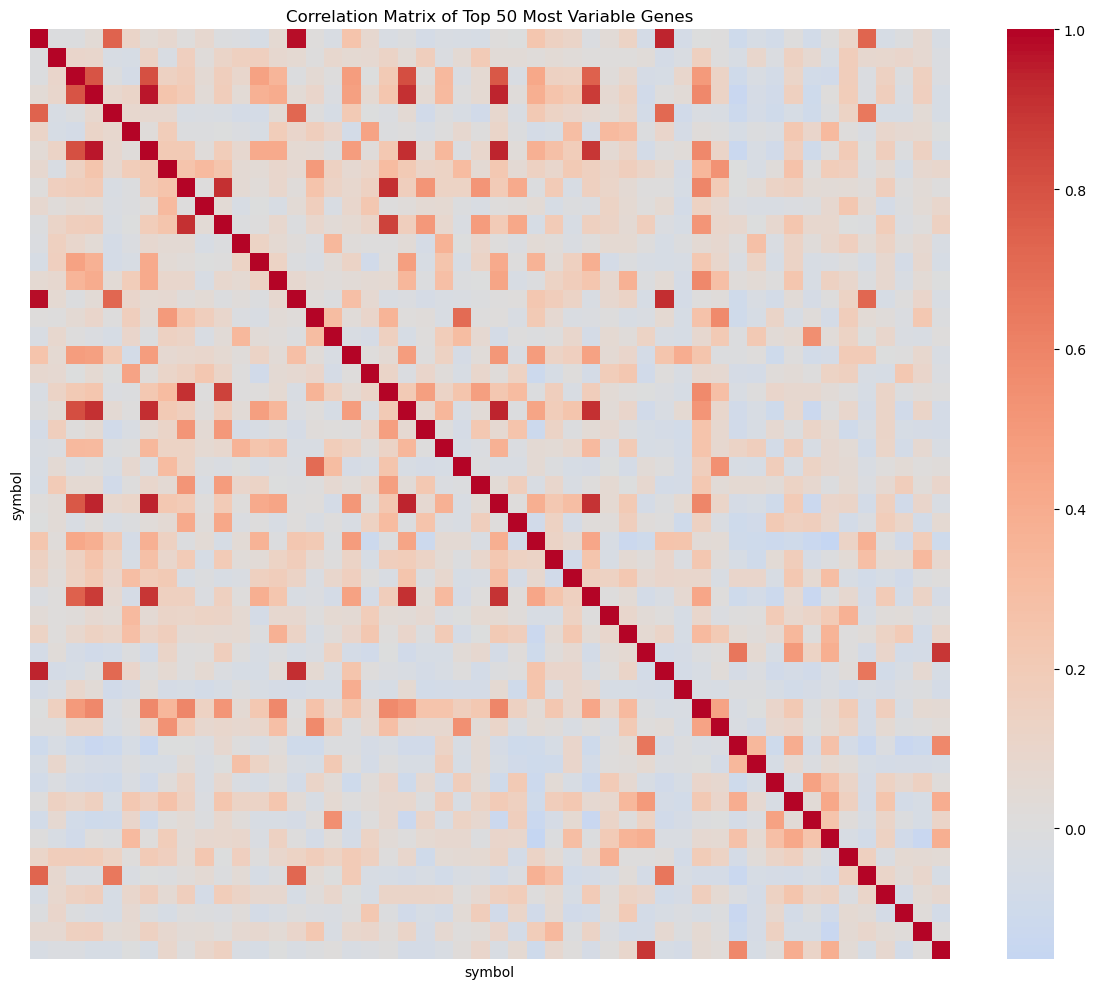

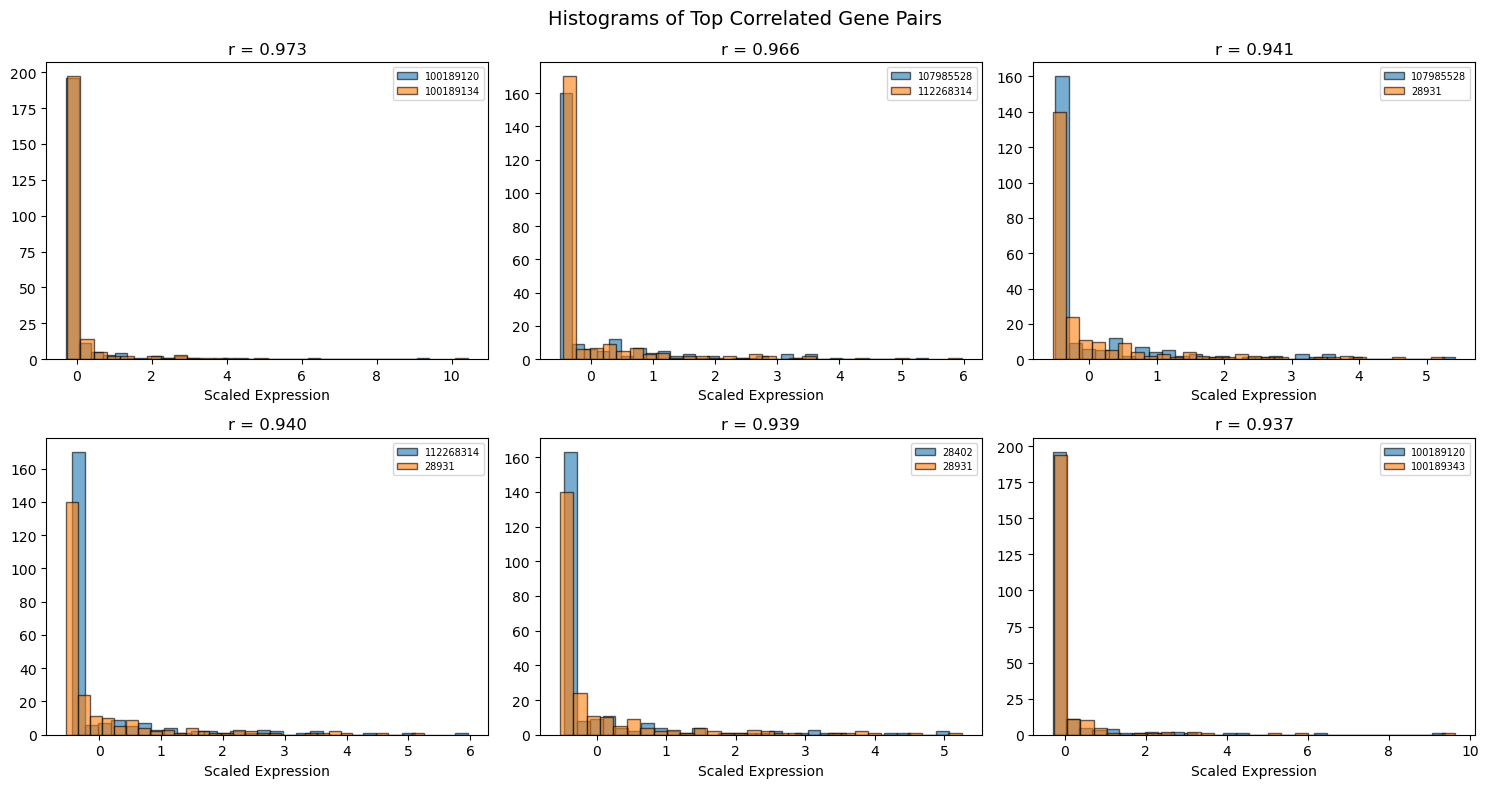

In [26]:
# --- Correlation matrix of top 50 most variable selected genes ---
gene_variance = df_selected.var(axis=1).sort_values(ascending=False)
top_var_genes = gene_variance.head(50).index
corr_matrix = df_selected.loc[top_var_genes].T.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title('Correlation Matrix of Top 50 Most Variable Genes')
plt.tight_layout()
plt.show()

# --- Histograms of top correlated gene pairs ---
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_pairs = corr_upper.stack().abs().sort_values(ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, ((gene1, gene2), corr_val) in enumerate(top_pairs.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_selected.loc[gene1], bins=30, alpha=0.6, label=gene1[:15], edgecolor='black')
    ax.hist(df_selected.loc[gene2], bins=30, alpha=0.6, label=gene2[:15], edgecolor='black')
    ax.set_title(f'r = {corr_val:.3f}')
    ax.legend(fontsize=7)
    ax.set_xlabel('Scaled Expression')
plt.suptitle('Histograms of Top Correlated Gene Pairs', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Unsupervised Learning
PCA to reduce dimensionality (retaining 90% variance), scatter plot visualization, K-means clustering of genes with elbow method.

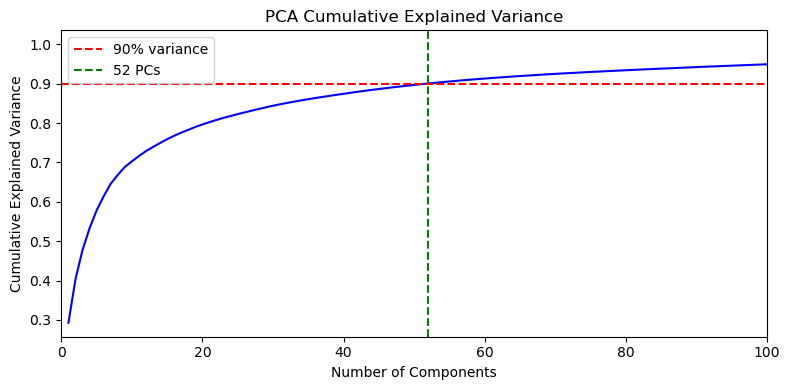

PCA-reduced data shape: (231, 52)


In [27]:
# --- PCA visualization (already computed above) ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} PCs')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.xlim(0, min(100, len(cumulative_var)))
plt.tight_layout()
plt.show()

print(f"PCA-reduced data shape: {X_pca.shape}")

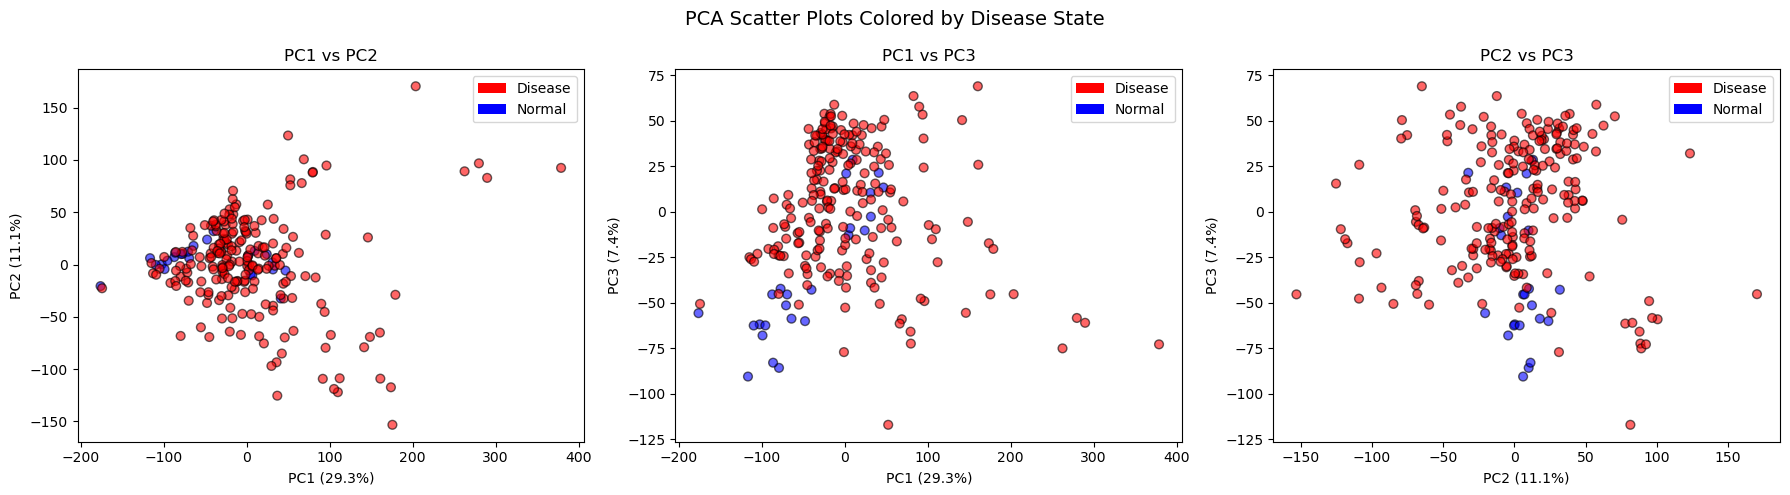

In [28]:
# --- PCA scatter plots colored by disease state ---
from matplotlib.patches import Patch

labels = meta_df.loc[df_scaled.columns, 'disease_state'].values
colors = ['red' if l == 'Disease' else 'blue' for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[0].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[1].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PC1 vs PC3')

axes[2].scatter(X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[2].set_xlabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[2].set_title('PC2 vs PC3')

legend_elements = [Patch(facecolor='red', label='Disease'), Patch(facecolor='blue', label='Normal')]
for ax in axes:
    ax.legend(handles=legend_elements)
plt.suptitle('PCA Scatter Plots Colored by Disease State', fontsize=14)
plt.tight_layout()
plt.show()

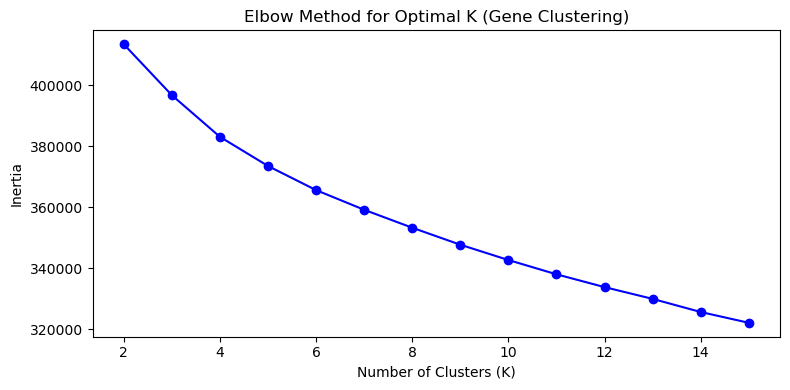

Optimal K selected: 5


In [29]:
from sklearn.cluster import KMeans

# --- K-means clustering of GENES based on expression profiles ---
# Genes as rows, samples as features
X_genes = df_selected.values  # (n_genes x n_samples)

# Elbow method
inertias = []
K_range = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_genes)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (Gene Clustering)')
plt.tight_layout()
plt.show()

# Select optimal K via maximum second derivative
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
optimal_k = list(K_range)[np.argmax(diffs2) + 2]
print(f"Optimal K selected: {optimal_k}")

Gene cluster sizes:
cluster
0    431
1    456
2     97
3    572
4    444
Name: count, dtype: int64


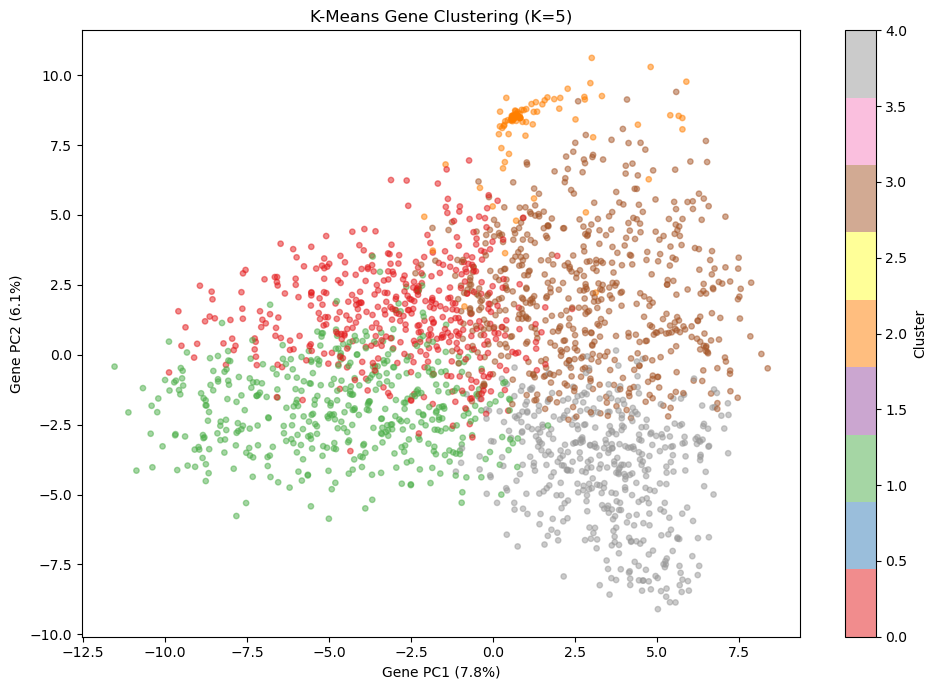

In [30]:
# --- Apply K-means to cluster genes ---
kmeans_genes = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
gene_cluster_labels = kmeans_genes.fit_predict(X_genes)

gene_clusters = pd.DataFrame({
    'gene': df_selected.index,
    'cluster': gene_cluster_labels
})

print("Gene cluster sizes:")
print(gene_clusters['cluster'].value_counts().sort_index())

# Visualize gene clusters using PCA on genes
pca_gene_viz = PCA(n_components=2)
X_genes_2d = pca_gene_viz.fit_transform(X_genes)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_genes_2d[:, 0], X_genes_2d[:, 1],
                      c=gene_cluster_labels, cmap='Set1', alpha=0.5, s=15)
plt.xlabel(f'Gene PC1 ({pca_gene_viz.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Gene PC2 ({pca_gene_viz.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Gene Clustering (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 4. Network Construction

### 4a. PPI Network from prebuilt adjacency (BME 357 Project Data/M_PPI.npz)

In [31]:
import networkx as nx
from scipy import sparse

# --- Load prebuilt PPI network ---
M_PPI = sparse.load_npz(DATA_DIR / "M_PPI.npz").tocsr()
ppi_name_arr = np.load(DATA_DIR / "PPI_name.npy", allow_pickle=True).squeeze()
ppi_names = np.array([str(np.asarray(n).item()) for n in ppi_name_arr])
ppi_idx = {g: i for i, g in enumerate(ppi_names)}

# Restrict to PCA-selected genes that exist in the PPI database
query_genes = df_selected.index.tolist()
ppi_genes_sel = [g for g in query_genes if g in ppi_idx]
print(f"PCA-selected genes mappable to PPI: {len(ppi_genes_sel)} / {len(query_genes)}")

ppi_pos = np.array([ppi_idx[g] for g in ppi_genes_sel])
M_PPI_sub = M_PPI[ppi_pos][:, ppi_pos].astype(np.uint8)
M_PPI_sub = M_PPI_sub.maximum(M_PPI_sub.T)  # treat as undirected
M_PPI_sub.setdiag(0)
M_PPI_sub.eliminate_zeros()

ppi_graph = nx.from_scipy_sparse_array(M_PPI_sub, edge_attribute="weight")
ppi_graph = nx.relabel_nodes(ppi_graph, {i: ppi_genes_sel[i] for i in range(len(ppi_genes_sel))})
ppi_graph.remove_nodes_from(list(nx.isolates(ppi_graph)))
print(f"PPI Network: {ppi_graph.number_of_nodes()} nodes, {ppi_graph.number_of_edges()} edges")

# PPI degree
ppi_degrees = dict(ppi_graph.degree())
ppi_degree_df = (
    pd.DataFrame(list(ppi_degrees.items()), columns=["gene", "ppi_degree"])
      .sort_values("ppi_degree", ascending=False)
)
print("\nTop 20 PPI hub genes:")
print(ppi_degree_df.head(20).to_string(index=False))


PCA-selected genes mappable to PPI: 872 / 2000
PPI Network: 866 nodes, 7732 edges

Top 20 PPI hub genes:
    gene  ppi_degree
     JUN         723
HSP90AA1         253
    CBX8         169
    ATF3         168
     FOS         162
    PTK6         151
   FAM9B         140
   NCOR1         139
 SLC6A20         135
    DAB1         135
  TWIST1         127
  S100A9         126
 FAM124B         122
    TGM2         120
  TFAP2C         120
    NAB2         119
    MDN1         118
    JUND         109
    PID1         108
   RPS26         107


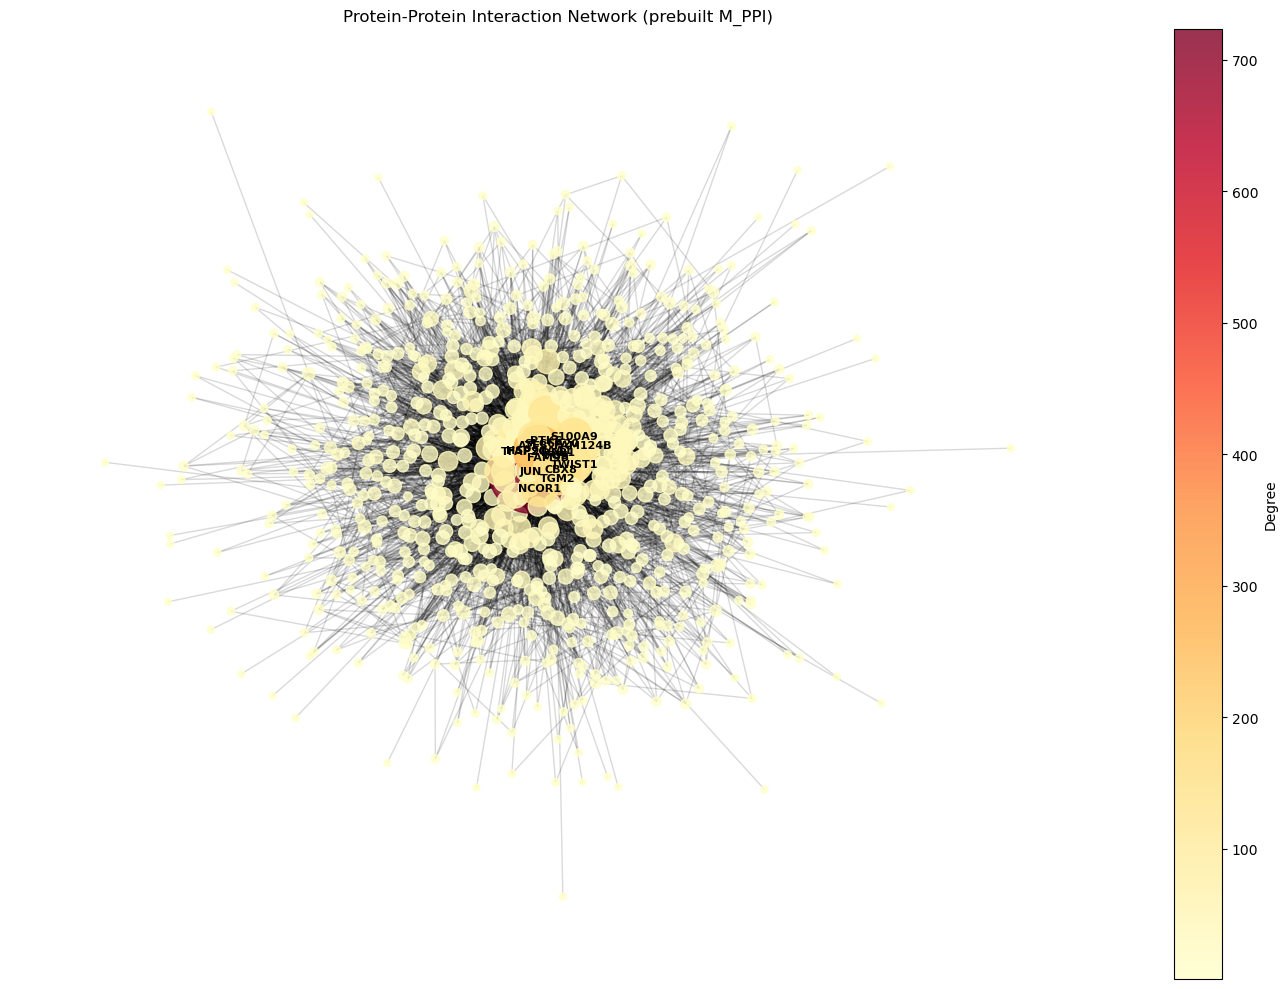

In [32]:
# --- Visualize PPI Network ---
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(ppi_graph, k=0.3, seed=42)

node_sizes = [ppi_degrees.get(n, 1) * 5 + 20 for n in ppi_graph.nodes()]
node_colors = [ppi_degrees.get(n, 0) for n in ppi_graph.nodes()]

nx.draw_networkx_edges(ppi_graph, pos, alpha=0.15)
nodes = nx.draw_networkx_nodes(ppi_graph, pos, node_size=node_sizes,
                                node_color=node_colors, cmap='YlOrRd', alpha=0.8)

top_hubs_ppi = ppi_degree_df.head(15)['gene'].tolist()
hub_labels = {n: n for n in ppi_graph.nodes() if n in top_hubs_ppi}
nx.draw_networkx_labels(ppi_graph, pos, labels=hub_labels, font_size=8, font_weight='bold')

plt.colorbar(nodes, label='Degree')
plt.title('Protein-Protein Interaction Network (prebuilt M_PPI)')
plt.axis('off')
plt.tight_layout()
plt.show()


### 4b. Gene Regulatory Network from prebuilt adjacency (BME 357 Project Data/M_GRN.npz)

In [33]:
from scipy import stats

# --- Load prebuilt GRN ---
M_GRN = sparse.load_npz(DATA_DIR / "M_GRN.npz").tocsr()
grn_name_arr = np.load(DATA_DIR / "GRN_name.npy", allow_pickle=True).squeeze()
grn_names = np.array([str(np.asarray(n).item()) for n in grn_name_arr])
grn_idx = {g: i for i, g in enumerate(grn_names)}

# Restrict to PCA-selected genes present in the GRN
grn_genes_sel = [g for g in df_selected.index if g in grn_idx]
print(f"PCA-selected genes mappable to GRN: {len(grn_genes_sel)} / {df_selected.shape[0]}")

grn_pos = np.array([grn_idx[g] for g in grn_genes_sel])
M_GRN_sub = M_GRN[grn_pos][:, grn_pos].astype(np.uint8)
M_GRN_sub = M_GRN_sub.maximum(M_GRN_sub.T)  # undirected for module/hub analysis
M_GRN_sub.setdiag(0)
M_GRN_sub.eliminate_zeros()

grn_graph = nx.from_scipy_sparse_array(M_GRN_sub, edge_attribute="weight")
grn_graph = nx.relabel_nodes(grn_graph, {i: grn_genes_sel[i] for i in range(len(grn_genes_sel))})
grn_graph.remove_nodes_from(list(nx.isolates(grn_graph)))
print(f"GRN: {grn_graph.number_of_nodes()} nodes, {grn_graph.number_of_edges()} edges")


PCA-selected genes mappable to GRN: 926 / 2000
GRN: 472 nodes, 1007 edges


In [34]:
from networkx.algorithms.community import greedy_modularity_communities

# --- Module detection: greedy modularity on the prebuilt GRN ---
if grn_graph.number_of_edges() > 0:
    communities = list(greedy_modularity_communities(grn_graph))
else:
    communities = []

gene_to_module = {}
for mod_id, community in enumerate(communities, start=1):
    for gene in community:
        gene_to_module[gene] = mod_id

module_labels = np.array([gene_to_module.get(g, -1) for g in df_selected.index])
gene_modules = pd.DataFrame({"gene": df_selected.index, "module": module_labels})
n_modules = len(communities)
print(f"GRN modules detected: {n_modules}")

print("\nGenes per module (top 15):")
mod_counts = gene_modules[gene_modules["module"] != -1]["module"].value_counts().sort_index()
print(mod_counts.head(15))
print(f"Genes not in any GRN module: {(gene_modules['module'] == -1).sum()}")


GRN modules detected: 12

Genes per module (top 15):
module
1     96
2     80
3     67
4     46
5     45
6     38
7     32
8     28
9     19
10    12
11     7
12     2
Name: count, dtype: int64
Genes not in any GRN module: 1528


In [35]:
# --- Module-trait correlation ---
y_binary = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values

module_trait_corr = {}
for mod in sorted(m for m in gene_modules["module"].unique() if m != -1):
    mod_genes = gene_modules[gene_modules["module"] == mod]["gene"].values
    if len(mod_genes) < 2:
        continue
    mod_expr = df_selected.loc[mod_genes].T.values
    me = PCA(n_components=1).fit_transform(mod_expr).flatten()
    r, p = stats.pearsonr(me, y_binary)
    module_trait_corr[mod] = (r, p)

print("Module-Disease Trait Correlations (top 20 by |r|):")
print(f"{'Module':<10} {'Correlation':>12} {'p-value':>12} {'Genes':>8}")
ranked = sorted(module_trait_corr.items(), key=lambda x: abs(x[1][0]), reverse=True)
for mod, (r, p) in ranked[:20]:
    n_genes = (gene_modules["module"] == mod).sum()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {mod:<8} {r:>12.4f} {p:>12.2e} {n_genes:>8} {sig}")

sig_modules = [mod for mod, (r, p) in module_trait_corr.items() if p < 0.05]
print(f"\nDisease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")


Module-Disease Trait Correlations (top 20 by |r|):
Module      Correlation      p-value    Genes
  9              0.3157     9.69e-07       19 ***
  1              0.3138     1.13e-06       96 ***
  6              0.2956     4.87e-06       38 ***
  8              0.2829     1.27e-05       28 ***
  5              0.2164     9.31e-04       45 ***
  4              0.2025     1.98e-03       46 **
  3              0.1753     7.56e-03       67 **
  2              0.1506     2.21e-02       80 *
  12             0.1371     3.74e-02        2 *
  11             0.1092     9.77e-02        7 
  10            -0.0766     2.46e-01       12 
  7             -0.0529     4.23e-01       32 

Disease-significant modules (p<0.05): 9/12


K-Means vs GRN Module Agreement (2000 genes):
  Adjusted Rand Index (ARI): -0.0051
  Normalized Mutual Information (NMI): 0.0221


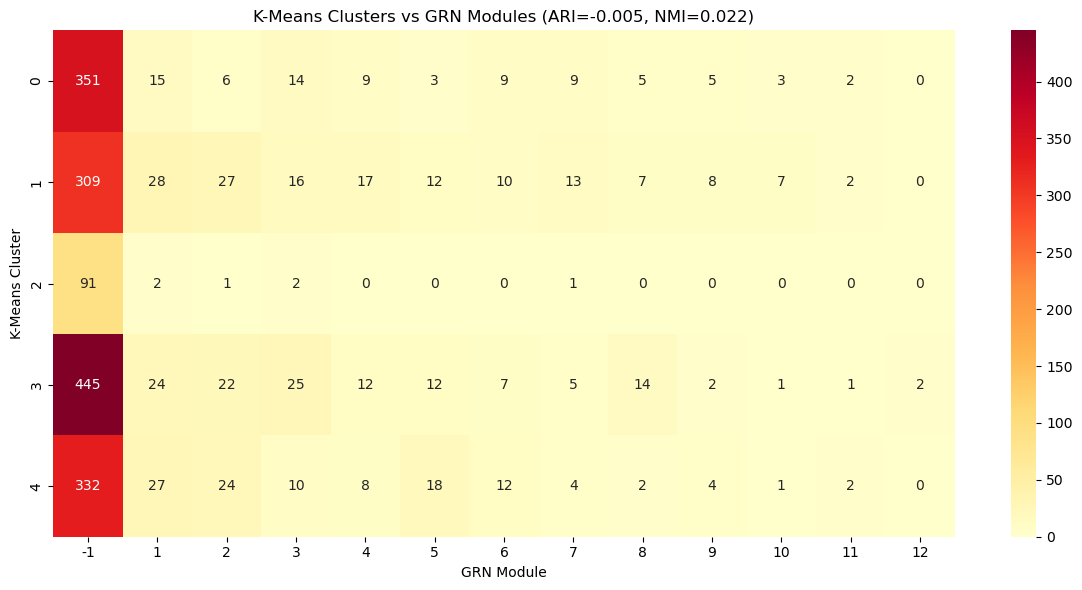

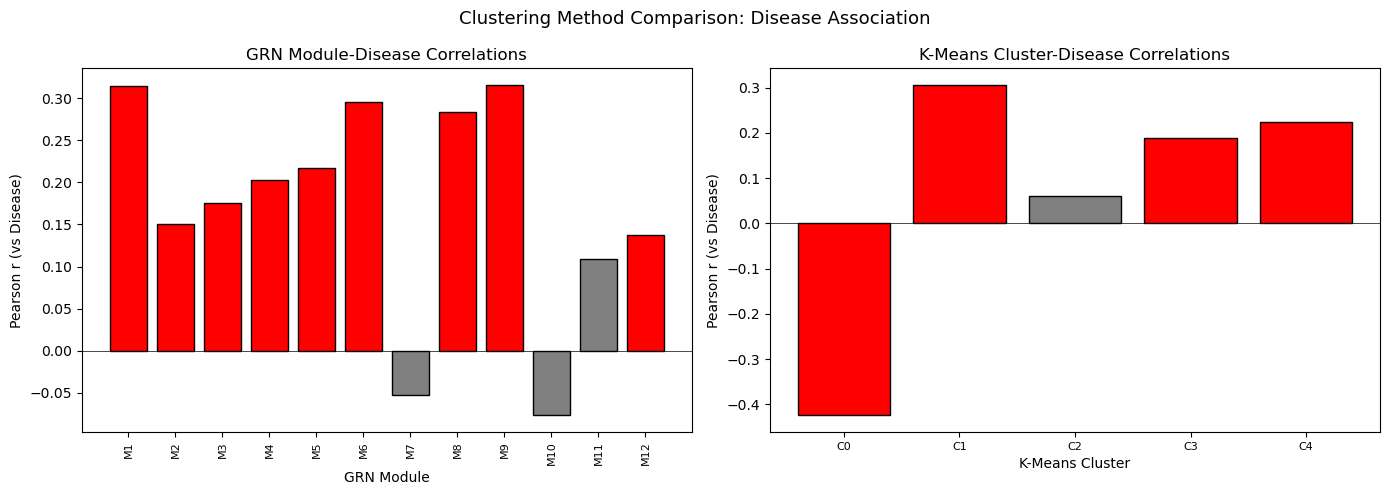


GRN disease-significant modules (p<0.05): 9/12
K-Means disease-significant clusters (p<0.05): 4/5


In [36]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- Compare K-Means Clusters vs GRN Modules ---
kmeans_labels = gene_clusters.set_index('gene')['cluster']
grn_module_labels = gene_modules.set_index('gene')['module']

shared_genes = kmeans_labels.index.intersection(grn_module_labels.index)
km_aligned = kmeans_labels.loc[shared_genes].values
gm_aligned = grn_module_labels.loc[shared_genes].values

ari = adjusted_rand_score(km_aligned, gm_aligned)
nmi = normalized_mutual_info_score(km_aligned, gm_aligned)
print(f"K-Means vs GRN Module Agreement ({len(shared_genes)} genes):")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi:.4f}")

contingency = pd.crosstab(
    pd.Series(km_aligned, name='K-Means Cluster'),
    pd.Series(gm_aligned, name='GRN Module')
)

plt.figure(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd')
plt.title(f'K-Means Clusters vs GRN Modules (ARI={ari:.3f}, NMI={nmi:.3f})')
plt.xlabel('GRN Module')
plt.ylabel('K-Means Cluster')
plt.tight_layout()
plt.show()

# Disease-trait correlation per K-means cluster
kmeans_trait_corr = {}
for cl in sorted(gene_clusters['cluster'].unique()):
    cl_genes = gene_clusters[gene_clusters['cluster'] == cl]['gene'].values
    cl_genes_in_data = [g for g in cl_genes if g in df_selected.index]
    if len(cl_genes_in_data) < 2:
        continue
    cl_expr = df_selected.loc[cl_genes_in_data].T.values
    eigengene = PCA(n_components=1).fit_transform(cl_expr).flatten()
    r, p = stats.pearsonr(eigengene, y_binary)
    kmeans_trait_corr[cl] = (r, p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grn_mods = sorted(module_trait_corr.keys())
grn_rs = [module_trait_corr[m][0] for m in grn_mods]
grn_ps = [module_trait_corr[m][1] for m in grn_mods]
colors_g = ['red' if p < 0.05 else 'gray' for p in grn_ps]
axes[0].bar(range(len(grn_mods)), grn_rs, color=colors_g, edgecolor='black')
axes[0].set_xticks(range(len(grn_mods)))
axes[0].set_xticklabels([f'M{m}' for m in grn_mods], fontsize=8, rotation=90)
axes[0].set_xlabel('GRN Module')
axes[0].set_ylabel('Pearson r (vs Disease)')
axes[0].set_title('GRN Module-Disease Correlations')
axes[0].axhline(0, color='black', linewidth=0.5)

km_cls = sorted(kmeans_trait_corr.keys())
km_rs = [kmeans_trait_corr[c][0] for c in km_cls]
km_ps = [kmeans_trait_corr[c][1] for c in km_cls]
colors_k = ['red' if p < 0.05 else 'gray' for p in km_ps]
axes[1].bar(range(len(km_cls)), km_rs, color=colors_k, edgecolor='black')
axes[1].set_xticks(range(len(km_cls)))
axes[1].set_xticklabels([f'C{c}' for c in km_cls], fontsize=8)
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Pearson r (vs Disease)')
axes[1].set_title('K-Means Cluster-Disease Correlations')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.suptitle('Clustering Method Comparison: Disease Association', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nGRN disease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")
km_sig = [c for c, (r, p) in kmeans_trait_corr.items() if p < 0.05]
print(f"K-Means disease-significant clusters (p<0.05): {len(km_sig)}/{len(kmeans_trait_corr)}")


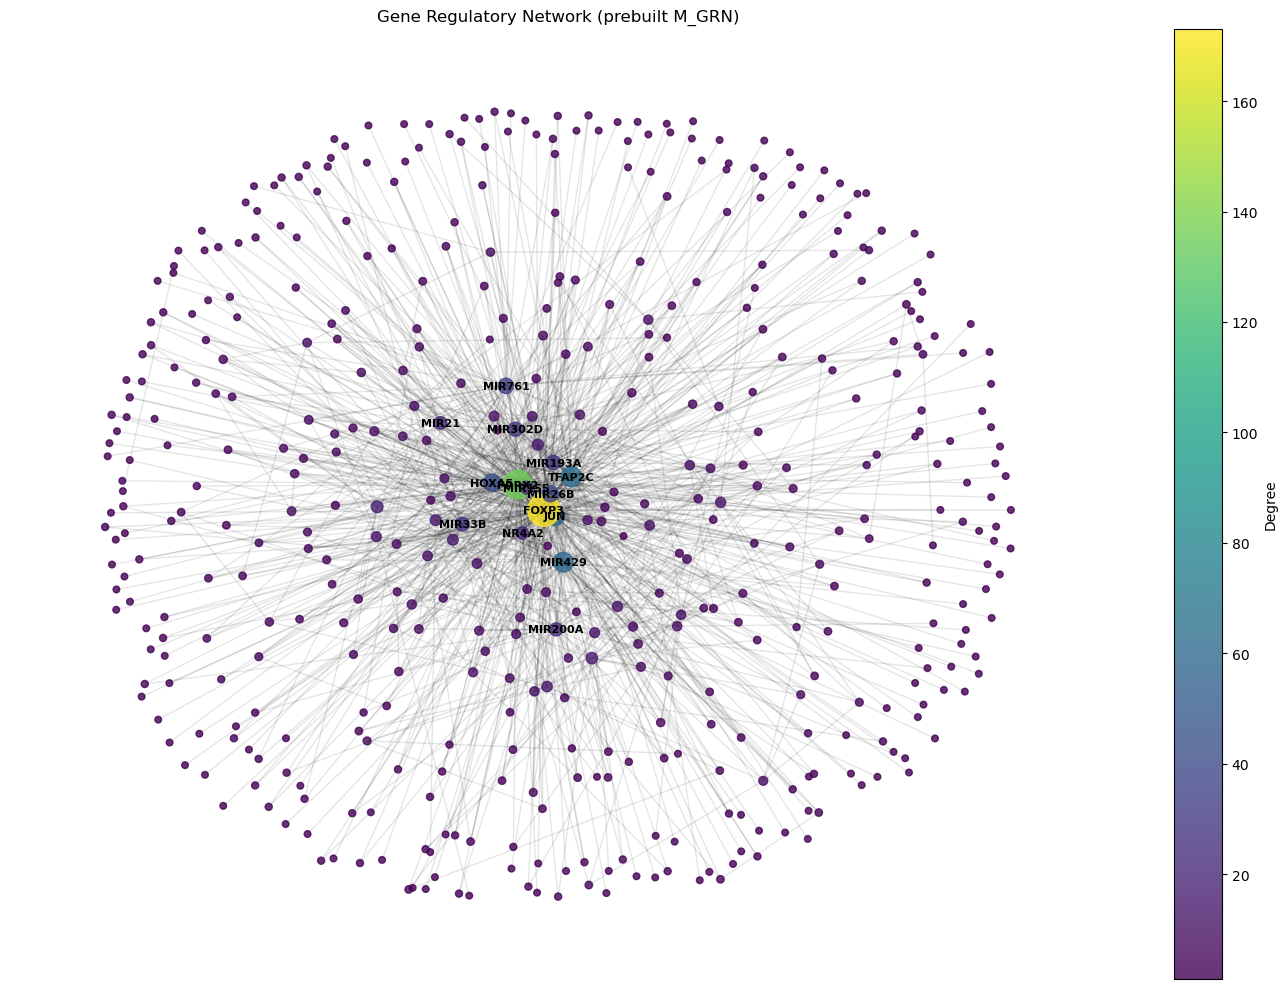

In [37]:
# --- Visualize GRN ---
plt.figure(figsize=(14, 10))
if grn_graph.number_of_nodes() > 0:
    pos_grn = nx.spring_layout(grn_graph, k=0.5, seed=42)
    grn_degrees = dict(grn_graph.degree())
    node_sizes_grn = [grn_degrees[n] * 3 + 20 for n in grn_graph.nodes()]
    node_colors_grn = [grn_degrees[n] for n in grn_graph.nodes()]

    nx.draw_networkx_edges(grn_graph, pos_grn, alpha=0.1)
    nodes_grn = nx.draw_networkx_nodes(grn_graph, pos_grn, node_size=node_sizes_grn,
                                        node_color=node_colors_grn, cmap='viridis', alpha=0.8)
    grn_degree_df = (
        pd.DataFrame(list(grn_degrees.items()), columns=['gene', 'grn_degree'])
          .sort_values('grn_degree', ascending=False)
    )
    top_hubs_grn = grn_degree_df.head(15)['gene'].tolist()
    hub_labels_grn = {n: n for n in grn_graph.nodes() if n in top_hubs_grn}
    nx.draw_networkx_labels(grn_graph, pos_grn, labels=hub_labels_grn, font_size=8, font_weight='bold')

    plt.colorbar(nodes_grn, label='Degree')
    plt.title('Gene Regulatory Network (prebuilt M_GRN)')
else:
    plt.text(0.5, 0.5, 'GRN is empty for selected genes.', ha='center', va='center', fontsize=14)
    plt.title('Gene Regulatory Network (empty)')
plt.axis('off')
plt.tight_layout()
plt.show()


## 5. Hub Gene Identification
Count connections in GRN and PPI, consolidate into a combined score, apply threshold.

Hub gene threshold (mean + 1 SD): 0.111
Number of hub genes identified: 53

Top 25 Hub Genes:
    gene  ppi_degree  grn_degree  combined_score
     JUN       723.0        58.0        1.335260
   FOXP3        35.0       173.0        1.048409
   PRRX2        13.0       135.0        0.798327
  TFAP2C       120.0        63.0        0.530137
HSP90AA1       253.0         9.0        0.401954
  MIR429         0.0        60.0        0.346821
    CBX8       169.0        12.0        0.303112
    ATF3       168.0         7.0        0.272828
   HOXA5         6.0        44.0        0.262634
     FOS       162.0         6.0        0.258748
    PTK6       151.0         4.0        0.231973
  MIR26B         0.0        38.0        0.219653
    DAB1       135.0         5.0        0.215624
   NCOR1       139.0         3.0        0.209596
   FAM9B       140.0         2.0        0.205198
 FAM124B       122.0         5.0        0.197643
  MIR761         0.0        34.0        0.196532
 SLC6A20       135.0    

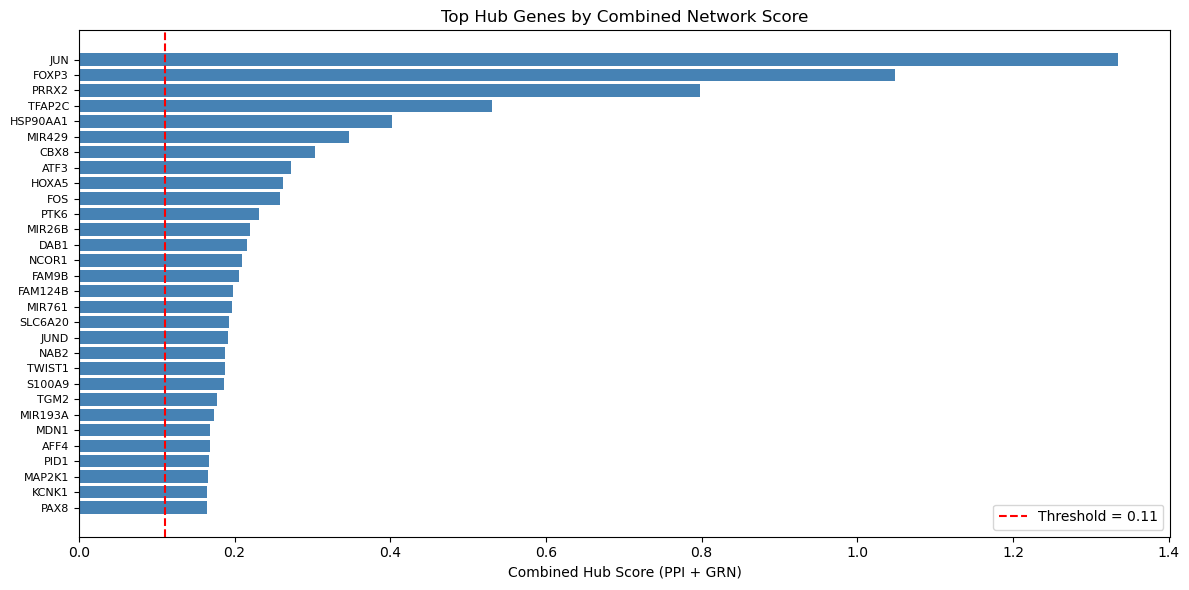

In [38]:
# --- Hub Gene Identification ---
# GRN degrees
if grn_graph.number_of_nodes() > 0:
    grn_degree_all = pd.DataFrame(list(dict(grn_graph.degree()).items()), columns=['gene', 'grn_degree'])
else:
    grn_degree_all = pd.DataFrame(columns=['gene', 'grn_degree'])

# Merge PPI + GRN degrees
hub_scores = pd.merge(ppi_degree_df, grn_degree_all, on='gene', how='outer').fillna(0)

# Normalize each to 0-1 and compute combined score
if hub_scores['ppi_degree'].max() > 0:
    hub_scores['ppi_norm'] = hub_scores['ppi_degree'] / hub_scores['ppi_degree'].max()
else:
    hub_scores['ppi_norm'] = 0
if hub_scores['grn_degree'].max() > 0:
    hub_scores['grn_norm'] = hub_scores['grn_degree'] / hub_scores['grn_degree'].max()
else:
    hub_scores['grn_norm'] = 0

hub_scores['combined_score'] = hub_scores['ppi_norm'] + hub_scores['grn_norm']
hub_scores = hub_scores.sort_values('combined_score', ascending=False)

# Threshold: mean + 1 SD
threshold = hub_scores['combined_score'].mean() + hub_scores['combined_score'].std()
hub_genes = hub_scores[hub_scores['combined_score'] >= threshold]['gene'].tolist()

print(f"Hub gene threshold (mean + 1 SD): {threshold:.3f}")
print(f"Number of hub genes identified: {len(hub_genes)}")
print(f"\nTop 25 Hub Genes:")
print(hub_scores.head(25)[['gene', 'ppi_degree', 'grn_degree', 'combined_score']].to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
top_n = min(30, len(hub_scores))
plt.barh(range(top_n), hub_scores.head(top_n)['combined_score'].values, color='steelblue')
plt.yticks(range(top_n), hub_scores.head(top_n)['gene'].values, fontsize=8)
plt.xlabel('Combined Hub Score (PPI + GRN)')
plt.title('Top Hub Genes by Combined Network Score')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Hub Gene Identification: PCA vs UMAP vs t-SNE (each + K-means)
Compare three unsupervised pipelines for finding hub genes: cluster genes after PCA, after UMAP, and after t-SNE. For each method, rank hub genes from disease-associated clusters, evaluate diagnostic performance with logistic-regression cross-validation, and compare against the network-based hubs from Section 5.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans

# --- Shared setup ---
N_HUBS = 30
K_CLUSTERS = optimal_k  # reuse K from elbow

y_disease = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values
X_genes_full = df_selected.values  # genes x samples

# Per-gene disease |t-statistic| (used to rank within disease-associated clusters)
gene_tstats = np.array([
    abs(stats.ttest_ind(
        df_selected.iloc[g].values[y_disease == 1],
        df_selected.iloc[g].values[y_disease == 0],
        equal_var=False,
    ).statistic)
    for g in range(df_selected.shape[0])
])
gene_tstats = np.nan_to_num(gene_tstats, nan=0.0)


def hubs_from_clusters(cluster_labels, top_n=N_HUBS):
    """Pick top-n hub genes: rank genes by |t-stat| within disease-associated clusters
    (p<0.05 by eigengene-disease correlation); fall back to global |t-stat| if no
    cluster passes."""
    cluster_assoc = {}
    for c in np.unique(cluster_labels):
        members = np.where(cluster_labels == c)[0]
        if len(members) < 2:
            continue
        eg = PCA(n_components=1).fit_transform(X_genes_full[members].T).flatten()
        r, p = stats.pearsonr(eg, y_disease)
        cluster_assoc[c] = (r, p, members)

    sig = [c for c, (_, p, _) in cluster_assoc.items() if p < 0.05]
    if sig:
        cand = np.concatenate([cluster_assoc[c][2] for c in sig])
    else:
        cand = np.arange(df_selected.shape[0])
    cand_sorted = sorted(set(cand), key=lambda i: -gene_tstats[i])
    return [df_selected.index[i] for i in cand_sorted[:top_n]], cluster_assoc


def evaluate_hubs(hub_genes):
    """5-fold CV LogReg AUC using hub-gene expression as features."""
    X = df_scaled.loc[hub_genes].T.values
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")
    aucs = cross_val_score(lr, X, y_disease, cv=cv, scoring="roc_auc")
    accs = cross_val_score(lr, X, y_disease, cv=cv, scoring="accuracy")
    return aucs, accs


# ============================================================
# Method A: PCA + K-means
# ============================================================
pca_for_hubs = PCA(n_components=min(20, X_genes_full.shape[1] - 1), random_state=42)
X_genes_pca = pca_for_hubs.fit_transform(X_genes_full)
km_pca = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_genes_pca)

hubs_pca, assoc_pca = hubs_from_clusters(labels_pca)
aucs_pca, accs_pca = evaluate_hubs(hubs_pca)

print(f"PCA+K-means: {len(hubs_pca)} hubs")
print(f"  CV AUC:      {aucs_pca.mean():.4f} +/- {aucs_pca.std():.4f}")
print(f"  CV Accuracy: {accs_pca.mean():.4f} +/- {accs_pca.std():.4f}")
print(f"  Top 10 hubs: {hubs_pca[:10]}")


In [ ]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

# ============================================================
# Method B: UMAP + K-means
# ============================================================
reducer = umap.UMAP(
    n_components=min(10, X_genes_full.shape[1] - 1),
    n_neighbors=15,
    min_dist=0.0,
    random_state=42,
)
X_genes_umap = reducer.fit_transform(X_genes_full)

km_umap = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_umap = km_umap.fit_predict(X_genes_umap)

hubs_umap, assoc_umap = hubs_from_clusters(labels_umap)
aucs_umap, accs_umap = evaluate_hubs(hubs_umap)

print(f"UMAP+K-means: {len(hubs_umap)} hubs")
print(f"  CV AUC:      {aucs_umap.mean():.4f} +/- {aucs_umap.std():.4f}")
print(f"  CV Accuracy: {accs_umap.mean():.4f} +/- {accs_umap.std():.4f}")
print(f"  Top 10 hubs: {hubs_umap[:10]}")


In [ ]:
from sklearn.manifold import TSNE

# ============================================================
# Method C: t-SNE + K-means
# ============================================================
n_genes = X_genes_full.shape[0]
tsne_perplexity = min(30, max(5, (n_genes - 1) // 3))
tsne = TSNE(
    n_components=3,
    perplexity=tsne_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto",
)
X_genes_tsne = tsne.fit_transform(X_genes_full)

km_tsne = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_tsne = km_tsne.fit_predict(X_genes_tsne)

hubs_tsne, assoc_tsne = hubs_from_clusters(labels_tsne)
aucs_tsne, accs_tsne = evaluate_hubs(hubs_tsne)

print(f"t-SNE+K-means: {len(hubs_tsne)} hubs (perplexity={tsne_perplexity})")
print(f"  CV AUC:      {aucs_tsne.mean():.4f} +/- {aucs_tsne.std():.4f}")
print(f"  CV Accuracy: {accs_tsne.mean():.4f} +/- {accs_tsne.std():.4f}")
print(f"  Top 10 hubs: {hubs_tsne[:10]}")


In [ ]:
# ============================================================
# Compare PCA+K-means vs UMAP+K-means vs t-SNE+K-means (and Section 5 network hubs)
# ============================================================
set_pca  = set(hubs_pca)
set_umap = set(hubs_umap)
set_tsne = set(hubs_tsne)
set_net  = set(hub_genes)  # from Section 5 network-degree hubs

def jaccard(a, b):
    return len(a & b) / max(len(a | b), 1)

method_sets = {
    "PCA+K-means":  set_pca,
    "UMAP+K-means": set_umap,
    "t-SNE+K-means": set_tsne,
    "Network":      set_net,
}

print("Pairwise hub-gene Jaccard:")
names = list(method_sets)
print(f"  {'':<14} " + " ".join(f"{n:<14}" for n in names))
for a in names:
    row = [f"  {a:<14}"]
    for b in names:
        row.append(f"{jaccard(method_sets[a], method_sets[b]):<14.3f}")
    print(" ".join(row))

print()
print(f"Shared by PCA & UMAP & t-SNE: {sorted(set_pca & set_umap & set_tsne)}")
print(f"Shared by all four:           {sorted(set_pca & set_umap & set_tsne & set_net)}")

summary = pd.DataFrame({
    "method": ["PCA+K-means", "UMAP+K-means", "t-SNE+K-means"],
    "n_hubs": [len(hubs_pca), len(hubs_umap), len(hubs_tsne)],
    "cv_auc_mean": [aucs_pca.mean(), aucs_umap.mean(), aucs_tsne.mean()],
    "cv_auc_std":  [aucs_pca.std(),  aucs_umap.std(),  aucs_tsne.std()],
    "cv_acc_mean": [accs_pca.mean(), accs_umap.mean(), accs_tsne.mean()],
    "cv_acc_std":  [accs_pca.std(),  accs_umap.std(),  accs_tsne.std()],
    "overlap_with_network": [len(set_pca & set_net), len(set_umap & set_net), len(set_tsne & set_net)],
})
print("\n", summary.to_string(index=False))


In [ ]:
# --- Visualize comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Venn of three clustering-based hub sets
plt.sca(axes[0])
try:
    from matplotlib_venn import venn3
    venn3(
        [set_pca, set_umap, set_tsne],
        set_labels=("PCA+K-means", "UMAP+K-means", "t-SNE+K-means"),
    )
    axes[0].set_title("Hub Gene Overlap (clustering methods)")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib-venn"])
    from matplotlib_venn import venn3
    venn3(
        [set_pca, set_umap, set_tsne],
        set_labels=("PCA+K-means", "UMAP+K-means", "t-SNE+K-means"),
    )
    axes[0].set_title("Hub Gene Overlap (clustering methods)")

# AUC bar chart
methods   = ["PCA+K-means", "UMAP+K-means", "t-SNE+K-means"]
auc_means = [aucs_pca.mean(), aucs_umap.mean(), aucs_tsne.mean()]
auc_stds  = [aucs_pca.std(),  aucs_umap.std(),  aucs_tsne.std()]
colors    = ["steelblue", "darkorange", "seagreen"]
axes[1].bar(methods, auc_means, yerr=auc_stds, capsize=6, color=colors, edgecolor="black")
axes[1].set_ylabel("5-fold CV AUC")
axes[1].set_title("Hub-Gene Diagnostic AUC by Method")
axes[1].set_ylim(0.0, 1.05)
for i, (m, s) in enumerate(zip(auc_means, auc_stds)):
    axes[1].text(i, m + 0.02, f"{m:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# --- Final summary ---
print("=" * 70)
print("HUB GENE METHOD COMPARISON - SUMMARY")
print("=" * 70)
print(f"Genes analyzed: {df_selected.shape[0]}  Samples: {df_selected.shape[1]}")
print(f"Top-N hubs per method: {N_HUBS}")
print(f"\nNetwork-based hubs (Section 5): {len(set_net)}")
print(f"PCA+K-means hubs:               {len(set_pca)}  CV-AUC = {aucs_pca.mean():.3f} +/- {aucs_pca.std():.3f}")
print(f"UMAP+K-means hubs:              {len(set_umap)}  CV-AUC = {aucs_umap.mean():.3f} +/- {aucs_umap.std():.3f}")
print(f"t-SNE+K-means hubs:             {len(set_tsne)}  CV-AUC = {aucs_tsne.mean():.3f} +/- {aucs_tsne.std():.3f}")
ranking = sorted(
    [("PCA+K-means", aucs_pca.mean()),
     ("UMAP+K-means", aucs_umap.mean()),
     ("t-SNE+K-means", aucs_tsne.mean())],
    key=lambda x: -x[1],
)
print(f"\nRanked by CV-AUC: " + " > ".join(f"{n} ({a:.3f})" for n, a in ranking))
print("=" * 70)
